In [3]:
import math
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [4]:
def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)


In [5]:
def make_two_spirals(n_per_class=600, noise=0.18):

    n = n_per_class
    t = np.linspace(0, 4 * math.pi, n)
    r = np.linspace(0.0, 1.0, n)

    x1 = np.c_[r*np.cos(t), r*np.sin(t)] + noise*np.random.randn(n,2)
    x2 = np.c_[r*np.cos(t+math.pi), r*np.sin(t+math.pi)] + noise*np.random.randn(n,2)

    X = np.vstack([x1,x2]).astype(np.float32)
    y = np.hstack([np.zeros(n,dtype=np.int32), np.ones(n,dtype=np.int32)])

    return X, y


In [6]:
def make_sine_regression(n=1600, noise=0.10):

    x = np.linspace(-3*math.pi,3*math.pi,n).reshape(-1,1).astype(np.float32)
    y = np.sin(x) + noise*np.random.randn(n,1).astype(np.float32)

    return x,y


In [7]:
def train_test_split(X,y,test_ratio=0.2):

    n = X.shape[0]
    idx = np.arange(n)
    np.random.shuffle(idx)

    test_size = int(n*test_ratio)

    test_idx = idx[:test_size]
    train_idx = idx[test_size:]

    return X[train_idx],X[test_idx],y[train_idx],y[test_idx]


In [8]:
def build_classifier(input_dim=2, hidden_dim=64, lr=1e-2):

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_dim, activation="relu"),
        layers.Dense(hidden_dim, activation="relu"),
        layers.Dense(2, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model


In [9]:
def build_regressor(input_dim=1, hidden_dim=64, lr=1e-3):

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_dim, activation="relu"),
        layers.Dense(hidden_dim, activation="relu"),
        layers.Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.MeanSquaredError(),
        metrics=[keras.metrics.MeanAbsoluteError()]
    )

    return model

In [10]:
def run_classification(hidden_dim=64, lr=1e-2, epochs=150, batch_size=64):

    set_seed()

    X,y = make_two_spirals()

    Xtr,Xte,ytr,yte = train_test_split(X,y)

    model = build_classifier(hidden_dim=hidden_dim, lr=lr)

    history = model.fit(
        Xtr,ytr,
        validation_data=(Xte,yte),
        epochs=epochs,
        batch_size=batch_size,
        verbose=2
    )

    loss,acc = model.evaluate(Xte,yte,verbose=0)

    print("Test Accuracy:",acc)

    return model,history


In [11]:
def run_regression(hidden_dim=64, lr=1e-3, epochs=300, batch_size=64):

    set_seed()

    X,y = make_sine_regression()

    Xtr,Xte,ytr,yte = train_test_split(X,y)

    model = build_regressor(hidden_dim=hidden_dim, lr=lr)

    history = model.fit(
        Xtr,ytr,
        validation_data=(Xte,yte),
        epochs=epochs,
        batch_size=batch_size,
        verbose=2
    )

    mse,mae = model.evaluate(Xte,yte,verbose=0)

    print("Test MSE:",mse)
    print("Test MAE:",mae)

    return model,history


In [12]:
run_classification(hidden_dim=16, lr=1e-2)
run_classification(hidden_dim=64, lr=1e-2)
run_classification(hidden_dim=128, lr=1e-2)
run_classification(hidden_dim=64, lr=1e-1)


Epoch 1/150
15/15 - 2s - 124ms/step - accuracy: 0.5354 - loss: 0.6866 - val_accuracy: 0.5375 - val_loss: 0.6720
Epoch 2/150
15/15 - 0s - 8ms/step - accuracy: 0.5615 - loss: 0.6793 - val_accuracy: 0.5292 - val_loss: 0.6676
Epoch 3/150
15/15 - 0s - 8ms/step - accuracy: 0.5656 - loss: 0.6762 - val_accuracy: 0.5333 - val_loss: 0.6644
Epoch 4/150
15/15 - 0s - 7ms/step - accuracy: 0.5646 - loss: 0.6754 - val_accuracy: 0.5375 - val_loss: 0.6621
Epoch 5/150
15/15 - 0s - 7ms/step - accuracy: 0.5688 - loss: 0.6736 - val_accuracy: 0.5542 - val_loss: 0.6605
Epoch 6/150
15/15 - 0s - 7ms/step - accuracy: 0.5740 - loss: 0.6726 - val_accuracy: 0.5583 - val_loss: 0.6589
Epoch 7/150
15/15 - 0s - 7ms/step - accuracy: 0.5719 - loss: 0.6708 - val_accuracy: 0.5667 - val_loss: 0.6576
Epoch 8/150
15/15 - 0s - 7ms/step - accuracy: 0.5719 - loss: 0.6694 - val_accuracy: 0.5750 - val_loss: 0.6567
Epoch 9/150
15/15 - 0s - 7ms/step - accuracy: 0.5740 - loss: 0.6673 - val_accuracy: 0.5750 - val_loss: 0.6556
Epoch 10

(<Sequential name=sequential_3, built=True>,
 <keras.src.callbacks.history.History at 0x7935c6e00cb0>)

In [13]:
run_regression(hidden_dim=16, lr=1e-3)
run_regression(hidden_dim=64, lr=1e-3)
run_regression(hidden_dim=128, lr=1e-3)
run_regression(hidden_dim=64, lr=1e-2)


Epoch 1/300
20/20 - 1s - 58ms/step - loss: 0.4970 - mean_absolute_error: 0.6158 - val_loss: 0.4768 - val_mean_absolute_error: 0.5948
Epoch 2/300
20/20 - 0s - 5ms/step - loss: 0.4885 - mean_absolute_error: 0.6109 - val_loss: 0.4609 - val_mean_absolute_error: 0.5859
Epoch 3/300
20/20 - 0s - 7ms/step - loss: 0.4805 - mean_absolute_error: 0.6057 - val_loss: 0.4623 - val_mean_absolute_error: 0.5867
Epoch 4/300
20/20 - 0s - 6ms/step - loss: 0.4803 - mean_absolute_error: 0.6058 - val_loss: 0.4616 - val_mean_absolute_error: 0.5857
Epoch 5/300
20/20 - 0s - 6ms/step - loss: 0.4791 - mean_absolute_error: 0.6041 - val_loss: 0.4613 - val_mean_absolute_error: 0.5850
Epoch 6/300
20/20 - 0s - 6ms/step - loss: 0.4779 - mean_absolute_error: 0.6029 - val_loss: 0.4610 - val_mean_absolute_error: 0.5841
Epoch 7/300
20/20 - 0s - 6ms/step - loss: 0.4749 - mean_absolute_error: 0.6002 - val_loss: 0.4577 - val_mean_absolute_error: 0.5814
Epoch 8/300
20/20 - 0s - 6ms/step - loss: 0.4714 - mean_absolute_error: 0.5

(<Sequential name=sequential_7, built=True>,
 <keras.src.callbacks.history.History at 0x7935c69aa360>)

In [14]:
def plot_history(history):

    plt.figure()

    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')

    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()


Epoch 1/150
15/15 - 1s - 86ms/step - accuracy: 0.5375 - loss: 0.6892 - val_accuracy: 0.5792 - val_loss: 0.6653
Epoch 2/150
15/15 - 0s - 8ms/step - accuracy: 0.5646 - loss: 0.6785 - val_accuracy: 0.5583 - val_loss: 0.6668
Epoch 3/150
15/15 - 0s - 8ms/step - accuracy: 0.5708 - loss: 0.6727 - val_accuracy: 0.5583 - val_loss: 0.6563
Epoch 4/150
15/15 - 0s - 7ms/step - accuracy: 0.5604 - loss: 0.6693 - val_accuracy: 0.5583 - val_loss: 0.6548
Epoch 5/150
15/15 - 0s - 7ms/step - accuracy: 0.5635 - loss: 0.6653 - val_accuracy: 0.5833 - val_loss: 0.6501
Epoch 6/150
15/15 - 0s - 8ms/step - accuracy: 0.5656 - loss: 0.6629 - val_accuracy: 0.5792 - val_loss: 0.6479
Epoch 7/150
15/15 - 0s - 8ms/step - accuracy: 0.5604 - loss: 0.6606 - val_accuracy: 0.6000 - val_loss: 0.6469
Epoch 8/150
15/15 - 0s - 7ms/step - accuracy: 0.5646 - loss: 0.6567 - val_accuracy: 0.5917 - val_loss: 0.6485
Epoch 9/150
15/15 - 0s - 7ms/step - accuracy: 0.5594 - loss: 0.6510 - val_accuracy: 0.5625 - val_loss: 0.6445
Epoch 10/

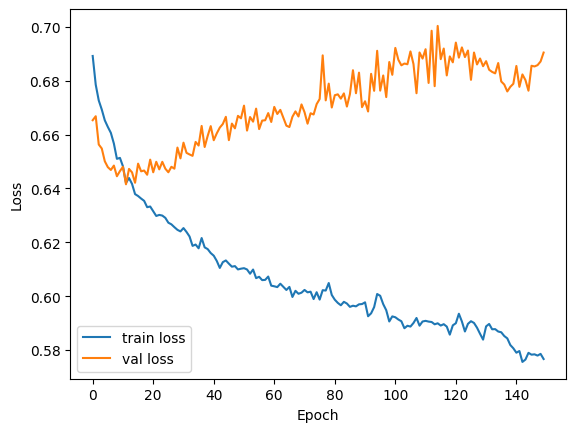

In [15]:
model,history = run_classification()
plot_history(history)


In [16]:
def plot_regression(model):

    X,y = make_sine_regression()

    pred = model.predict(X)

    plt.scatter(X,y,s=10,label="data")
    plt.plot(X,pred,color="red",label="prediction")

    plt.legend()
    plt.show()

In [ ]:
plot_regression()

In [20]:
cls_model, cls_hist = run_classification(
    hidden_dim=64,
    lr=1e-2,
    epochs=150,
    batch_size=64
)

Epoch 1/150
15/15 - 1s - 82ms/step - accuracy: 0.5427 - loss: 0.6905 - val_accuracy: 0.5792 - val_loss: 0.6681
Epoch 2/150
15/15 - 0s - 7ms/step - accuracy: 0.5573 - loss: 0.6804 - val_accuracy: 0.5417 - val_loss: 0.6694
Epoch 3/150
15/15 - 0s - 7ms/step - accuracy: 0.5635 - loss: 0.6737 - val_accuracy: 0.5708 - val_loss: 0.6567
Epoch 4/150
15/15 - 0s - 8ms/step - accuracy: 0.5698 - loss: 0.6705 - val_accuracy: 0.5708 - val_loss: 0.6564
Epoch 5/150
15/15 - 0s - 8ms/step - accuracy: 0.5646 - loss: 0.6675 - val_accuracy: 0.5708 - val_loss: 0.6545
Epoch 6/150
15/15 - 0s - 8ms/step - accuracy: 0.5656 - loss: 0.6651 - val_accuracy: 0.5667 - val_loss: 0.6513
Epoch 7/150
15/15 - 0s - 8ms/step - accuracy: 0.5667 - loss: 0.6611 - val_accuracy: 0.5750 - val_loss: 0.6501
Epoch 8/150
15/15 - 0s - 8ms/step - accuracy: 0.5792 - loss: 0.6574 - val_accuracy: 0.6042 - val_loss: 0.6481
Epoch 9/150
15/15 - 0s - 8ms/step - accuracy: 0.5760 - loss: 0.6533 - val_accuracy: 0.5792 - val_loss: 0.6468
Epoch 10/

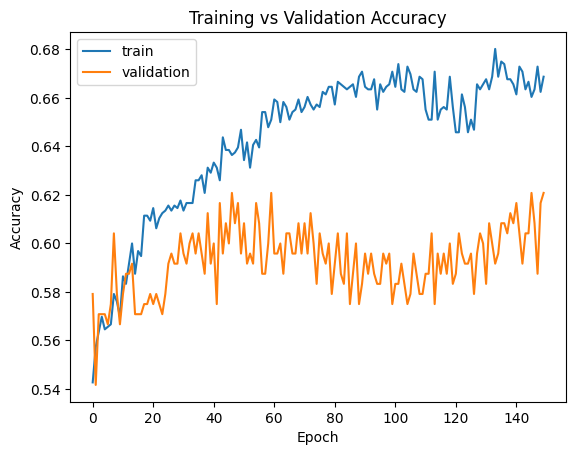

In [21]:
import matplotlib.pyplot as plt

plt.plot(cls_hist.history['accuracy'])
plt.plot(cls_hist.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["train","validation"])

plt.show()